In [1]:
%load_ext autoreload
%autoreload 2

from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
from search_inputs import inputs, getSearchMap, download_location
import os
from ipyleaflet import Map, basemaps

In [2]:
inputs

Box(children=(DatePicker(value=datetime.datetime(2025, 7, 1, 0, 0), description='Start Date:'), DatePicker(val…

In [3]:
m, searchState = getSearchMap(inputs, basemap=basemaps.Esri.WorldImagery)
m

Map(center=[37.5531, -109.6914], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', '…

["'type': 'REVERSE': 'report': Reversed polygon winding order"]


## Select a path
Once selected, the next cell will show you the footprints of the scenes that will actually be downloaded.

In [13]:
paths = searchState.pathSelector()
paths

Dropdown(description='Relative Orbit:', options=(('Path 26, DESCENDING (3)', 26), ('Path 119, ASCENDING (5)', …

Updated Path


In [14]:
# searchState.summaryMap(basemap=basemaps.Esri.WorldImagery)
searchState.summaryMap()

Map(center=[37.5531, -109.6914], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', '…

## File Preparation and Download/Mosaic
The following cells aggregate scenes by date, and then use gdal's vsicurl prefixes to download cropped and mosaiced scenes of just your study area.

### First pick a download location

In [16]:
download_location

Text(value='/data2/rb894/SAR/NISAR/nc_test', description='Folder:', placeholder='//Enter/Valid/Folder/Paths')

In [19]:
polarizations = ['HH', 'HV']

In [17]:
dates = [scene.properties['startTime'].split('T')[0] for scene in searchState.scenes2download]
udates = np.unique(np.array(dates))
print(f'Number of dates: {len(udates)}')

frames = [scene.properties['frameNumber'] for scene in searchState.scenes2download]
uframes = np.unique(np.array(frames))
# for scene in searchState.scenes2download:
#     print(scene.properties['url'])


Number of dates: 5


In [18]:
download_folder = download_location.value

if not os.path.exists(download_folder):
    os.makedirs(download_folder)

target_extent = searchState.search_coordinates
latitudes = [coord[1] for coord in searchState.search_coordinates]
longitudes = [coord[0] for coord in searchState.search_coordinates]
te = f'{np.min(longitudes)} {np.min(latitudes)} {np.max(longitudes)} {np.max(latitudes)}'

In [38]:
bash_script = ''
bash_path = os.path.join(download_folder, './dl.sh')

for d in udates:
    files2download = [scene.properties['url'] for scene in searchState.scenes2download if d in scene.properties['startTime']]
    for pol in polarizations:
        outpath = os.path.join(download_folder, f"./{d.replace('-', '')}_{pol}.tif")
        bandName = f'/science/LSAR/GSLC/grids/frequencyA/{pol}'
        # print(pol)
        # bandName = f'/science/LSAR/GSLC/grids/frequencyA/'
        files2download_pol = [f'NETCDF:/vsicurl/{file}:{bandName}' for file in files2download]
        # print(files2download_pol)
        gdal_command = f"gdalwarp -te {te} -te_srs EPSG:4326 \
    -srcnodata nan -dstnodata nan -r nearest -wo INIT_DEST=NO_DATA \
    -of GTiff -overwrite {' '.join(files2download_pol)} {outpath}"
        bash_script += gdal_command

        if d != udates[-1] or pol != polarizations[-1]:
            bash_script += ' & \n'

bash_script += ' \nwait'
with open(bash_path, "w") as dlsh:
    dlsh.write(bash_script)

HH
['NETCDF:/vsicurl/https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GSLC_BETA_V1/NISAR_L2_PR_GSLC_003_127_D_071_4005_DHDH_A_20251026T002723_20251026T002758_X05009_N_F_J_001/NISAR_L2_PR_GSLC_003_127_D_071_4005_DHDH_A_20251026T002723_20251026T002758_X05009_N_F_J_001.h5:/science/LSAR/GSLC/grids/frequencyA/HH']
HV
['NETCDF:/vsicurl/https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GSLC_BETA_V1/NISAR_L2_PR_GSLC_003_127_D_071_4005_DHDH_A_20251026T002723_20251026T002758_X05009_N_F_J_001/NISAR_L2_PR_GSLC_003_127_D_071_4005_DHDH_A_20251026T002723_20251026T002758_X05009_N_F_J_001.h5:/science/LSAR/GSLC/grids/frequencyA/HV']
HH
['NETCDF:/vsicurl/https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GSLC_BETA_V1/NISAR_L2_PR_GSLC_004_127_D_071_4005_DHDH_A_20251107T002724_20251107T002758_X05009_N_F_J_001/NISAR_L2_PR_GSLC_004_127_D_071_4005_DHDH_A_20251107T002724_20251107T002758_X05009_N_F_J_001.h5:/science/LSAR/GSLC/grids/frequencyA/HH']
HV
['NETCDF:/vsicurl/https://nisar.asf.eart

## Run download script
The for-loop above generates the gdal commmands for downloading the GSLCS to disk so that they can be run either in this notebook or also in a screen while the terminal is closed. To run in a screen, 
```
screen -S dlnisar
bash <bash_path.sh>
```
Then press `ctr+a d` to allow the downloads to run in the background.

Or run the script directly from this notebook below.

In [34]:
!bash {bash_path}

ERROR 1: Failed to parse NETCDF: prefix string into expected 2, 3 or 4 fields.
ERROR 1: Failed to parse NETCDF: prefix string into expected 2, 3 or 4 fields.
ERROR 1: Failed to parse NETCDF: prefix string into expected 2, 3 or 4 fields.
ERROR 1: Failed to parse NETCDF: prefix string into expected 2, 3 or 4 fields.
ERROR 4: Failed to open source file NETCDF:/vsicurl/NETCDF:/vsicurl/https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GSLC_BETA_V1/NISAR_L2_PR_GSLC_003_127_D_071_4005_DHDH_A_20251026T002723_20251026T002758_X05009_N_F_J_001/NISAR_L2_PR_GSLC_003_127_D_071_4005_DHDH_A_20251026T002723_20251026T002758_X05009_N_F_J_001.h5:/science/LSAR/GSLC/grids/frequencyA/HH:/science/LSAR/GSLC/grids/frequencyA/HV

ERROR 4: Failed to open source file NETCDF:/vsicurl/NETCDF:/vsicurl/https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GSLC_BETA_V1/NISAR_L2_PR_GSLC_010_127_D_071_4005_DHDH_A_20260118T002727_20260118T002801_X05010_N_F_J_001/NISAR_L2_PR_GSLC_010_127_D_071_4005_DHDH_A_2026011

## Preview Data
Load the first image below and seee if it looks alright!

In [30]:
import glob
import rasterio
from scipy.ndimage import uniform_filter
gslc_paths = sorted(glob.glob(os.path.join(download_folder, './*.tif')))
# gslc_paths = glob.glob('/data2/rb894/SAR/NISAR/kilauea/*.tif')
print(gslc_paths)
slc1 = rasterio.open(gslc_paths[1]).read(1)
slc2 = rasterio.open(gslc_paths[2]).read(1)

amp_ratio = 10 * np.log10(np.abs(slc2)/np.abs(slc1))
amp_ratio = uniform_filter(amp_ratio, size=(15, 15))
plt.imshow(amp_ratio , vmin=-6, vmax=-1)
plt.show()

infgm = uniform_filter(slc2 * slc1.conj(), size=(25, 25))
plt.imshow(np.angle(infgm), vmin=-np.pi, vmax=np.pi, cmap='RdBu_r', interpolation='none')

plt.show()

['/data2/rb894/SAR/NISAR/gsm/./20251026_HH.tif']


IndexError: list index out of range

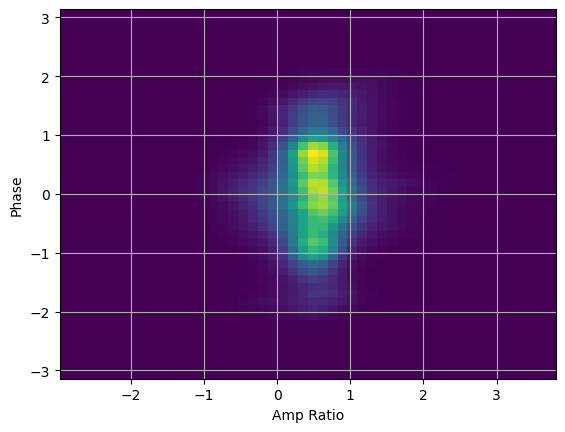

In [153]:
plt.hist2d(amp_ratio.flatten(), np.angle(infgm).flatten(), bins=50)
plt.xlabel('Amp Ratio')
plt.ylabel('Phase')
plt.grid()
plt.show()